In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
df.dtypes.value_counts()

,count
object,18
int64,2
float64,1


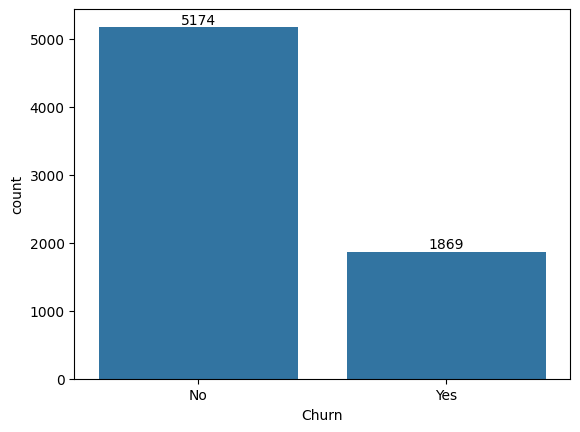

In [12]:
import seaborn as sns
ax=sns.countplot(x="Churn",data=df)
ax.bar_label(ax.containers[0])
plt.show()


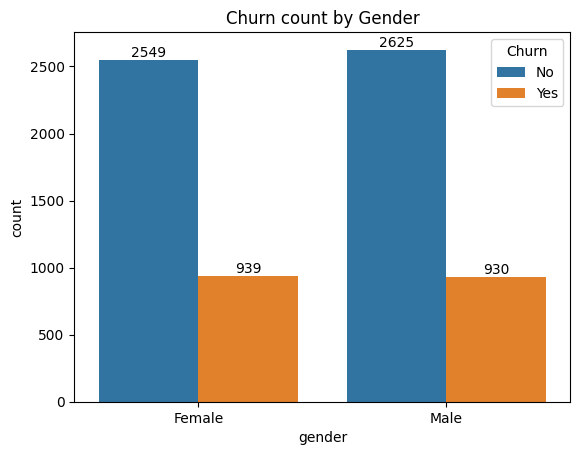

In [13]:
ax=sns.countplot(x="gender",hue="Churn", data=df)

for container in ax.containers:
  ax.bar_label(container)
  plt.title("Churn count by Gender")
plt.show()

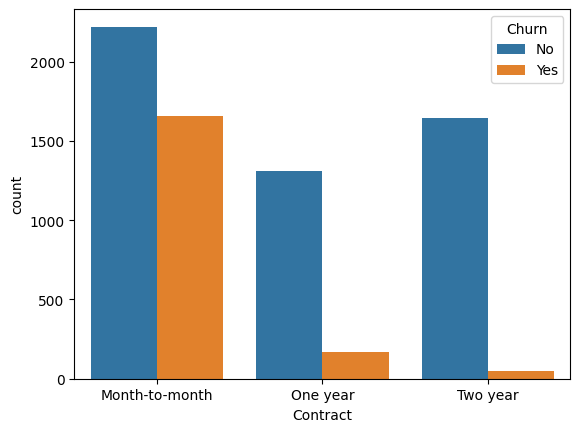

In [14]:
sns.countplot(x="Contract",hue="Churn",data=df)
plt.show()

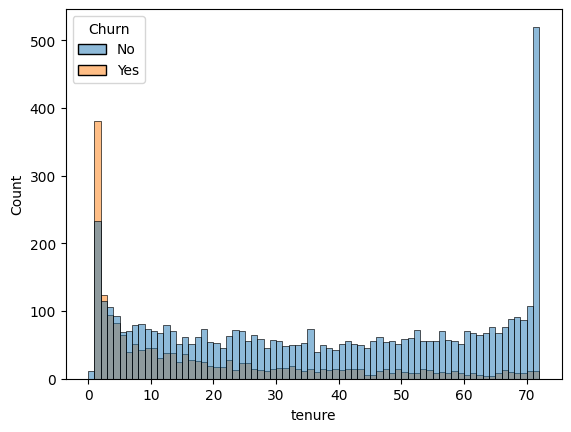

In [15]:
sns.histplot(x="tenure",hue="Churn",data=df,bins=72)
plt.show()

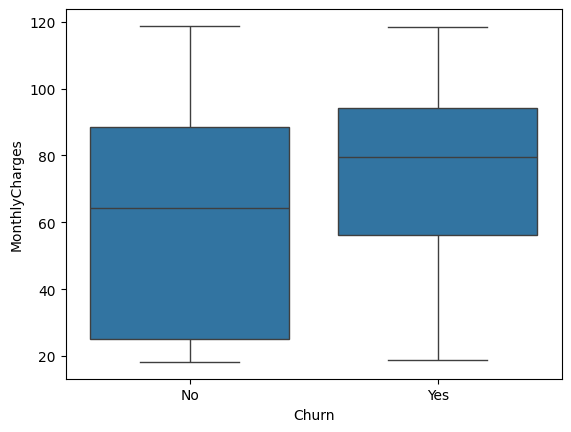

In [16]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.show()


Data cleaning and preprocessing

In [17]:
df["TotalCharges"].dtype

dtype('O')

In [18]:
df["TotalCharges"].head(10)


,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [19]:
(df["TotalCharges"]==" ").sum()

np.int64(11)

In [20]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")


In [21]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [22]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [23]:
df=df.dropna()

In [24]:
df.shape

(7032, 21)

In [25]:
df=df.drop("customerID",axis=1)

In [26]:
df.shape

(7032, 20)

In [27]:
df.duplicated().sum()

np.int64(22)

In [28]:
df=df.drop_duplicates()

In [29]:
df.shape

(7010, 20)

In [30]:
####Categorical Encoding-Convert text to numbers

In [31]:
####Those coluns that contain two values-yes /no etc will be converted to 0/1 -label encoding
####columns with more than 2 values like contracts-one month/one year/ two year will be converted by one-hot encoding


In [32]:
df["InternetService"].value_counts()

,count
InternetService,
Fiber optic,3090
DSL,2414
No,1506


In [33]:
two_value_columns=["Churn","Partner","Dependents","PhoneService","PaperlessBilling","gender"]
for col in two_value_columns:
  df[col]=df[col].map({"Yes":1,"No":0,"Male":1,"Female":0})

In [34]:
df[two_value_columns].head()

,Churn,Partner,Dependents,PhoneService,PaperlessBilling,gender
0,0,1,0,0,1,0
1,0,0,0,1,0,1
2,1,0,0,1,1,1
3,0,0,0,0,0,1
4,1,0,0,1,1,0


In [35]:
multi_value_columns=df.select_dtypes(include="object").columns
print(multi_value_columns)

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')


In [36]:
####applying one-hot encoding


In [37]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [38]:
df.shape

(7010, 20)

In [39]:
df = pd.get_dummies(df, columns=multi_value_columns, drop_first=True)

In [40]:
df.dtypes


,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
MonthlyCharges,float64
TotalCharges,float64
Churn,int64


In [41]:
df.dtypes.value_counts()

,count
bool,21
int64,8
float64,2


In [42]:
####Seperating feature and target SPLIT DATASET

In [43]:
X=df.drop(["Churn"],axis=1)
Y=df["Churn"]
#### drop(labels,axis =row/column)

In [44]:
####Now train test split
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [45]:
#80% training data , 20% testing, random_state=42 ensures reproducability

In [46]:
print(df.dtypes)
print(df.head())

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

Logistics Regression

In [47]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,Y_train)

coef=model.coef_[0]
intercept=model.intercept_[0]


print("model coefficients are", coef)
print("model intercept is", intercept)

model coefficients are [-2.47701908e-02  3.11231093e-01  4.15691756e-02 -2.51138551e-01
 -6.73290423e-02 -4.30849536e-01  4.43213101e-01  4.64902547e-03
  3.78015466e-04  3.08453111e-01  2.49198355e-01  4.82931595e-01
 -1.19432988e-01 -1.19432988e-01 -5.72450107e-01 -1.19432988e-01
 -2.03290620e-01 -1.19432988e-01 -1.30437954e-01 -1.19432988e-01
 -5.27033187e-01 -1.19432988e-01  1.51696309e-01 -1.19432988e-01
  1.80220904e-01 -4.41391697e-01 -6.59979340e-01 -1.35451431e-01
  2.29632369e-01 -3.48717446e-02]
model intercept is -0.12457888261510164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
print("model coefficients are", coef)
print("model intercept is", intercept)

model coefficients are [-2.47701908e-02  3.11231093e-01  4.15691756e-02 -2.51138551e-01
 -6.73290423e-02 -4.30849536e-01  4.43213101e-01  4.64902547e-03
  3.78015466e-04  3.08453111e-01  2.49198355e-01  4.82931595e-01
 -1.19432988e-01 -1.19432988e-01 -5.72450107e-01 -1.19432988e-01
 -2.03290620e-01 -1.19432988e-01 -1.30437954e-01 -1.19432988e-01
 -5.27033187e-01 -1.19432988e-01  1.51696309e-01 -1.19432988e-01
  1.80220904e-01 -4.41391697e-01 -6.59979340e-01 -1.35451431e-01
  2.29632369e-01 -3.48717446e-02]
model intercept is -0.12457888261510164


In [49]:
####prediction
y_pred=model.predict(X_test)


In [50]:
####Performance
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print ("Accuracy:" ,accuracy_score(Y_test,y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test,y_pred))
print("Classification Report :\n ", classification_report(Y_test,y_pred))


####confusion matrix-> TP=CHURN PREDICTED CORRECTLY
#TN-> NO CHURN PREDICTED CORRECTLY
#FP-> PREDICTED CHURN BUT ACTUALLY NO CHURN(FALSE POSITIVES)
#FN-> PREDICTED NO CHURN BUT ACTUALLY CHURN (FALSE NEGATIVES)


####Accuracy score->percentage of correct predictions

Accuracy: 0.8238231098430813
Confusion Matrix:
 [[972 109]
 [138 183]]
Classification Report :
                precision    recall  f1-score   support

           0       0.88      0.90      0.89      1081
           1       0.63      0.57      0.60       321

    accuracy                           0.82      1402
   macro avg       0.75      0.73      0.74      1402
weighted avg       0.82      0.82      0.82      1402



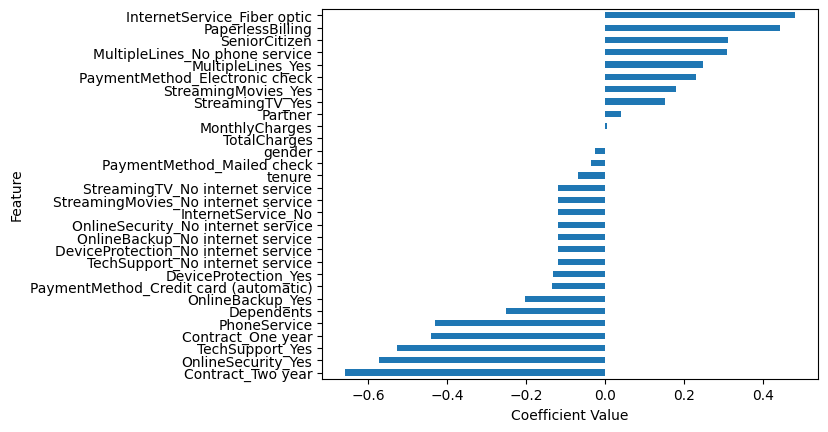

In [51]:
coef_series=pd.Series(coef,index=X_train.columns)
coef_series=coef_series.sort_values()

coef_series.plot(kind="barh")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()


####this shows which features increase or decrease the likelihood of churn

Random Forest


Each tress votes on churn prediction
n_estimators->100 trees


In [52]:
from sklearn.ensemble import RandomForestClassifier

model_rf=RandomForestClassifier(n_estimators=100,random_state=42)
model_rf.fit(X_train,Y_train)
y_pred_rf=model_rf.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_rf))
print("Classification report:", classification_report(Y_test, y_pred_rf))

Random Forest Accuracy: 0.8138373751783167
Confusion Matrix:
 [[971 110]
 [151 170]]
Classification report:               precision    recall  f1-score   support

           0       0.87      0.90      0.88      1081
           1       0.61      0.53      0.57       321

    accuracy                           0.81      1402
   macro avg       0.74      0.71      0.72      1402
weighted avg       0.81      0.81      0.81      1402



In [53]:
importance=pd.Series(model_rf.feature_importances_,index=X_train.columns)
importance=importance.sort_values()
print(importance.head())

DeviceProtection_No internet service    0.003468
MultipleLines_No phone service          0.003997
PhoneService                            0.004426
StreamingTV_No internet service         0.004640
TechSupport_No internet service         0.004975
dtype: float64


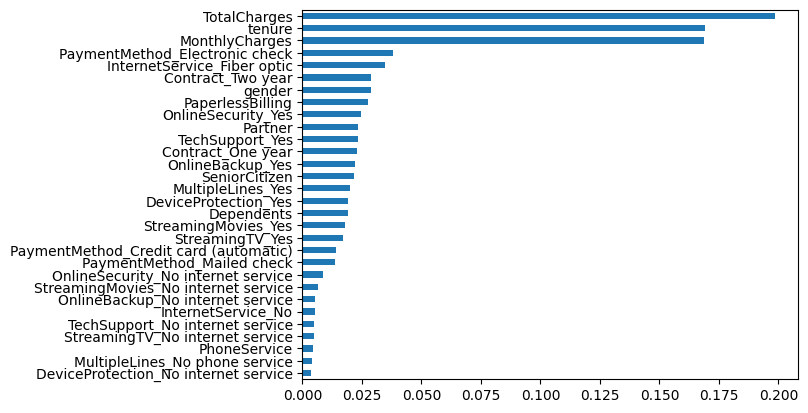

In [54]:
importance.plot(kind='barh')
plt.show()

Naive Bayes

In [55]:
from sklearn.naive_bayes import GaussianNB

In [56]:
model_nb=GaussianNB()

In [57]:
model_nb.fit(X_train,Y_train)

GaussianNB()

In [58]:
y_pred_nb=model_nb.predict(X_test)

In [59]:
print("Naive Bayes Accuracy:", accuracy_score(Y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_nb))
print("Classification Report:\n", classification_report(Y_test, y_pred_nb))

Naive Bayes Accuracy: 0.645506419400856
Confusion Matrix:
 [[618 463]
 [ 34 287]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.57      0.71      1081
           1       0.38      0.89      0.54       321

    accuracy                           0.65      1402
   macro avg       0.67      0.73      0.62      1402
weighted avg       0.82      0.65      0.67      1402



KNN CLASSIFIER


In [67]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

X_train_sc=sc.fit_transform(X_train)
X_test_sc=sc.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier


model_knn=KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train_sc,Y_train)
y_pred_knn=model_knn.predict(X_test_sc)

print("KNN Accuracy:", accuracy_score(Y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_knn))
print("Classification Report:\n", classification_report(Y_test, y_pred_knn))




KNN Accuracy: 0.7660485021398002
Confusion Matrix:
 [[902 179]
 [149 172]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1081
           1       0.49      0.54      0.51       321

    accuracy                           0.77      1402
   macro avg       0.67      0.69      0.68      1402
weighted avg       0.77      0.77      0.77      1402



SVM classifier


In [68]:
from sklearn.svm import SVC

# SVM also needs scaled data like KNN
model_svm = SVC(probability=True, random_state=42)
model_svm.fit(X_train_sc, Y_train)
y_pred_svm = model_svm.predict(X_test_sc)

print("SVM Accuracy:", accuracy_score(Y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_svm))
print("Classification Report:\n", classification_report(Y_test, y_pred_svm))

SVM Accuracy: 0.8209700427960057
Confusion Matrix:
 [[986  95]
 [156 165]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.89      1081
           1       0.63      0.51      0.57       321

    accuracy                           0.82      1402
   macro avg       0.75      0.71      0.73      1402
weighted avg       0.81      0.82      0.81      1402



Evaluation

In [61]:
#Area under ROC


In [62]:
#### Sensitivity(SN) TPR=SN and FPR=(1-sensitivity(SP))

In [63]:
####SN=TP/TP+FN AND SP=TN/TN+FP

In [64]:
####ROC-AUC -How well each model discriminates churn vs non-churn


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


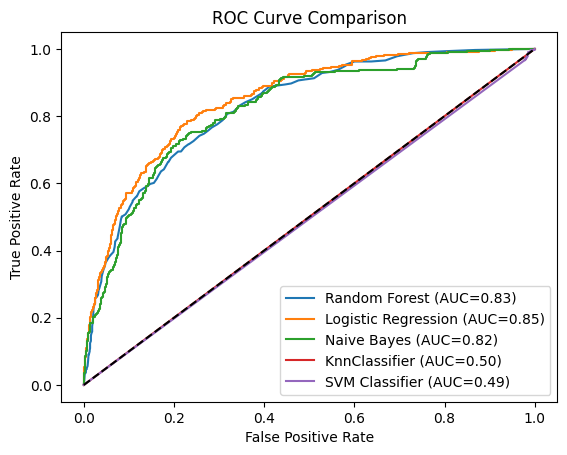

In [69]:

from sklearn.metrics import roc_curve, roc_auc_score


models = {
    "Random Forest": model_rf,
    "Logistic Regression": model,
    "Naive Bayes": model_nb,
    "KnnClassifier":model_knn,
    "SVM Classifier":model_svm
}



for name, mdl in models.items():
    y_prob = mdl.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    auc = roc_auc_score(Y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# Plot diagonal line
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()